# CML regime separability — measured directly on existing 50-instance runs

**Hypothesis under test.** The contiguous M-window cropped from a 100-site CML lattice loses regime-defining dynamics whenever M < lattice_M. Loose anchor clusters in 2D/3D embeddings of the existing pyspi feature pipeline are the symptom.

**Data.** `features/data-embeddings-proof_benchmarked_full_260424_pearson.npz` — already-cached SPI-SPI Pearson features from `process_features.py` over `proof-benchmarked-full.yaml` (50 instances × 3 M × 3 T × 20 classes). We restrict to the 10 CML regimes. Some M=20, T=2000 cells are partial (n<50) due to cluster walltime; cells with n<30 are flagged.

**What this notebook does.** For each (M, T) cell, compute three things in the SPI-SPI feature space the embedding pipeline actually uses:
1. Per-regime within-class scatter (mean-sq-dist to centroid).
2. Per-regime mean silhouette.
3. Leave-one-out logistic-regression accuracy + confusion matrix.

Then, for each regime, plot within-class scatter as M grows. If the loose-cluster effect is a window-position artefact, scatter should drop monotonically with M (toward zero at M=lattice_M=100, which we cannot directly test without a new run).

**What this notebook does NOT do.** It does not vary `crop_offset`. The existing data uses centred-crop only, but each instance has a different IC, so for static-structure regimes (frozen-chaos, TWs) IC randomness already exposes window-position sensitivity to the centroid. A direct offset-axis sweep would test it more cleanly — but only after this baseline tells us whether the effect is detectable at all.

In [1]:
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict

F = np.load('../../features/data-embeddings-proof_benchmarked_full_260424_pearson.npz', allow_pickle=True)
X_all, y_all = F['X'], F['y']
M_all, T_all = F['M'].astype(int), F['T'].astype(int)
CML = ['frozen-chaos','pattern-selection','brownian-defect','defect-turbulence','sti-i','sti-ii','fdstc','traveling-wave','chaotic-traveling-wave','traveling-wave-kaneko67']
mask_cml = np.isin(y_all, CML)
X, y, M, T = X_all[mask_cml], y_all[mask_cml], M_all[mask_cml], T_all[mask_cml]
print(f'Restricted to CML: {X.shape}; cells (M,T) → counts:')
print(pd.Series(Counter(zip(M, T))).sort_index().to_string())

Restricted to CML: (3948, 42486); cells (M,T) → counts:
5   500     300
    1000    383
    2000    500
10  500     500
    1000    500
    2000    500
20  500     500
    1000    500
    2000    265


## 1. Per-(M, T)-cell diagnostics across CML regimes

For each cell with sufficient n: standardise (drop dead features), compute silhouette per regime, LOO classifier per-regime recall, and within-class scatter.

In [2]:
def cell_diagnostic(Xc, yc, min_per_class=20):
    counts = pd.Series(yc).value_counts()
    keep_classes = counts[counts >= min_per_class].index.tolist()
    if len(keep_classes) < 2:
        return None
    m = np.isin(yc, keep_classes)
    Xc, yc = Xc[m], yc[m]
    alive = Xc.std(axis=0) > 1e-8
    Xs = StandardScaler().fit_transform(Xc[:, alive])
    Xs = np.nan_to_num(Xs, nan=0.0, posinf=0.0, neginf=0.0)
    labels_idx = pd.Categorical(yc, categories=keep_classes).codes
    sil = silhouette_samples(Xs, labels_idx, metric='euclidean')
    clf = LogisticRegression(max_iter=2000, C=1.0)
    preds = cross_val_predict(clf, Xs, labels_idx, cv=LeaveOneOut())
    out = []
    for i, r in enumerate(keep_classes):
        sel = labels_idx == i
        Xr = Xs[sel]
        scatter = float(((Xr - Xr.mean(0)) ** 2).sum(axis=1).mean())
        out.append({
            'regime': r, 'n': int(sel.sum()),
            'silhouette': float(sil[sel].mean()),
            'recall_loo': float((preds[sel] == i).mean()),
            'within_scatter': scatter,
        })
    return pd.DataFrame(out).set_index('regime')

cells = sorted(set(zip(M.tolist(), T.tolist())))
results = {}
for (Mv, Tv) in cells:
    sel = (M == Mv) & (T == Tv)
    df = cell_diagnostic(X[sel], y[sel])
    if df is not None:
        results[(Mv, Tv)] = df
        print(f'\n=== M={Mv} T={Tv}  (n_total={int(sel.sum())}) ===')
        print(df.round(2))


=== M=5 T=500  (n_total=300) ===
                         n  silhouette  recall_loo  within_scatter
regime                                                            
chaotic-traveling-wave  50        0.02        0.72        23280.54
defect-turbulence       50        0.29        1.00        18101.92
frozen-chaos            50        0.05        0.96        26920.78
pattern-selection       50        0.03        0.84        22943.99
sti-i                   50        0.05        1.00        41388.92
traveling-wave          50       -0.02        0.90        28001.67

=== M=5 T=1000  (n_total=383) ===
                         n  silhouette  recall_loo  within_scatter
regime                                                            
brownian-defect         50       -0.02        0.94        28888.29
chaotic-traveling-wave  50        0.02        0.78        22187.57
defect-turbulence       50        0.31        1.00        13701.88
fdstc                   50        0.33        1.00        11

## 2. Within-class scatter as a function of M (the window-shrinkage test)

For each regime at fixed T, plot within-class scatter vs M. The hypothesis predicts:
- **Static / coherent regimes** (frozen-chaos, traveling-waves, pattern-selection): scatter declines with M (window captures more of the spatial structure as it grows).
- **Mobile / well-mixed regimes** (defect-turbulence, fdstc, sti-ii, brownian-defect): scatter ≈ flat in M (windows interchangeable already).

If everything is flat, the loose-cluster phenomenon is *not* about window size; look elsewhere (zscoring, SPI subset, embedding hyperparameters).

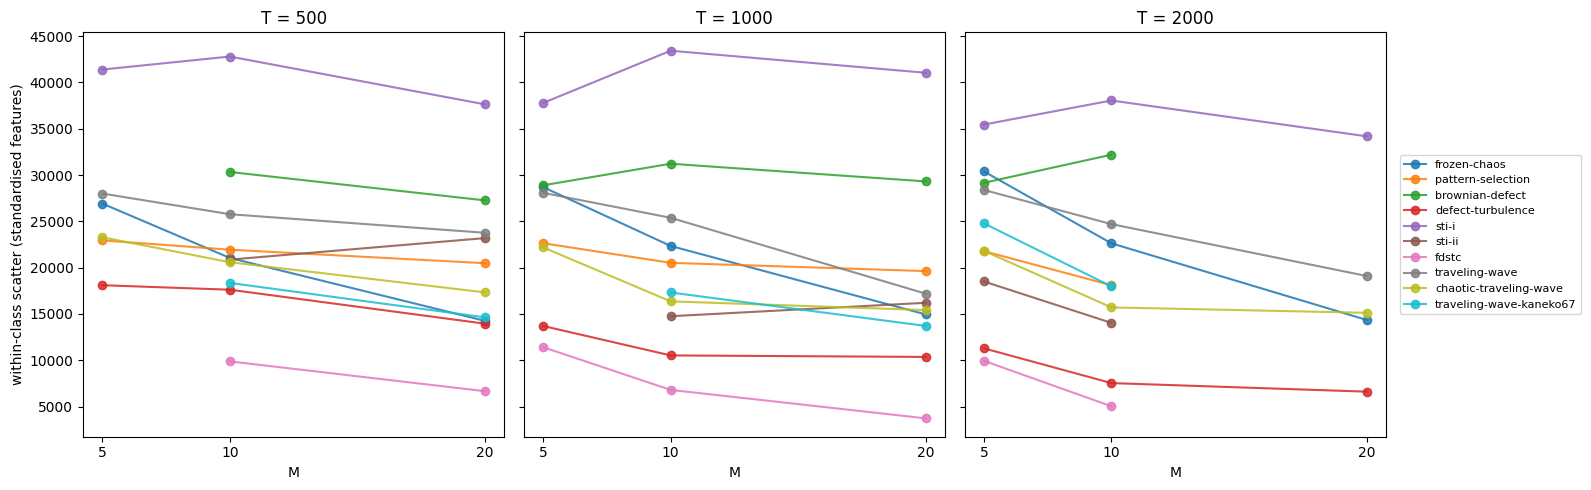

In [3]:
rows = []
for (Mv, Tv), df in results.items():
    for r, row in df.iterrows():
        rows.append({'regime': r, 'M': Mv, 'T': Tv, **row.to_dict()})
long = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, T_target in zip(axes, [500, 1000, 2000]):
    sub = long[long['T'] == T_target]
    for r in CML:
        d = sub[sub['regime'] == r].sort_values('M')
        if len(d) < 2: continue
        ax.plot(d['M'], d['within_scatter'], '-o', label=r, alpha=0.85)
    ax.set_xlabel('M'); ax.set_title(f'T = {T_target}')
    ax.set_xticks([5, 10, 20])
axes[0].set_ylabel('within-class scatter (standardised features)')
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout(); plt.show()

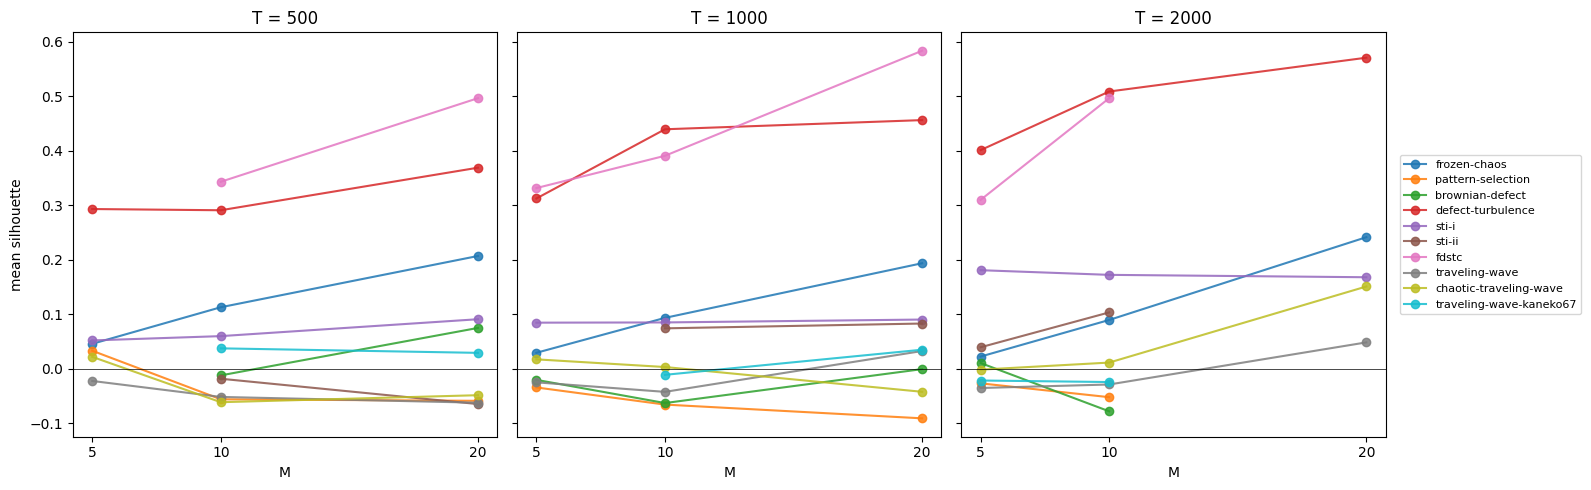

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, T_target in zip(axes, [500, 1000, 2000]):
    sub = long[long['T'] == T_target]
    for r in CML:
        d = sub[sub['regime'] == r].sort_values('M')
        if len(d) < 2: continue
        ax.plot(d['M'], d['silhouette'], '-o', label=r, alpha=0.85)
    ax.set_xlabel('M'); ax.set_title(f'T = {T_target}')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xticks([5, 10, 20])
axes[0].set_ylabel('mean silhouette')
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout(); plt.show()

## 3. Confusion matrix at the cell of interest

Pick the (M, T) you actually use downstream and inspect which regimes get confused with which. This is the actionable failure mode — "loose cluster" is too vague.

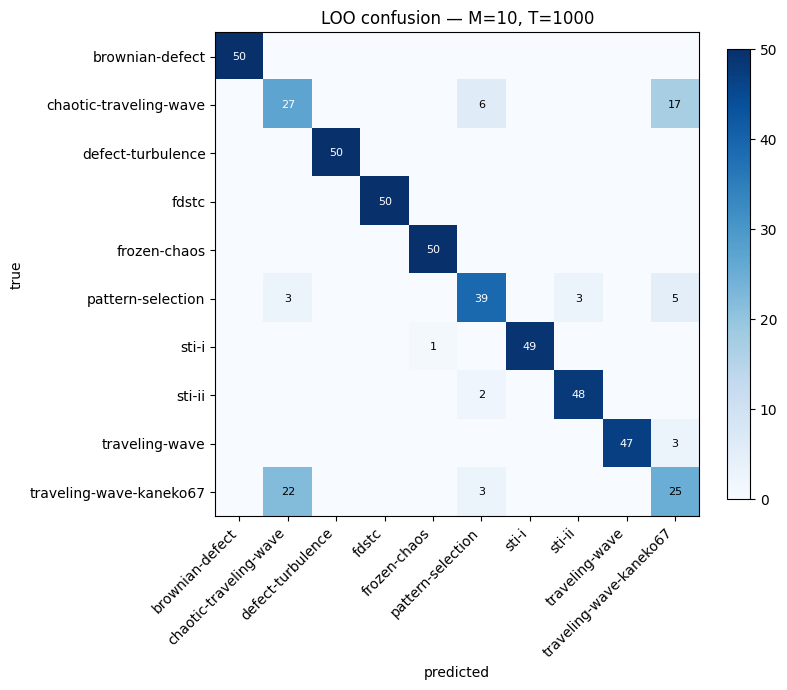

                         precision    recall  f1-score   support

        brownian-defect       1.00      1.00      1.00        50
 chaotic-traveling-wave       0.52      0.54      0.53        50
      defect-turbulence       1.00      1.00      1.00        50
                  fdstc       1.00      1.00      1.00        50
           frozen-chaos       0.98      1.00      0.99        50
      pattern-selection       0.78      0.78      0.78        50
                  sti-i       1.00      0.98      0.99        50
                 sti-ii       0.94      0.96      0.95        50
         traveling-wave       1.00      0.94      0.97        50
traveling-wave-kaneko67       0.50      0.50      0.50        50

               accuracy                           0.87       500
              macro avg       0.87      0.87      0.87       500
           weighted avg       0.87      0.87      0.87       500



In [5]:
Mv, Tv = 10, 1000  # change to whatever cell drives the embedding you're analysing
sel = (M == Mv) & (T == Tv)
Xc, yc = X[sel], y[sel]
counts = pd.Series(yc).value_counts(); keep = counts[counts >= 20].index.tolist()
m2 = np.isin(yc, keep); Xc, yc = Xc[m2], yc[m2]
alive = Xc.std(axis=0) > 1e-8
Xs = StandardScaler().fit_transform(Xc[:, alive]); Xs = np.nan_to_num(Xs)
lbl = pd.Categorical(yc, categories=keep).codes
preds = cross_val_predict(LogisticRegression(max_iter=2000, C=1.0), Xs, lbl, cv=LeaveOneOut())
cm = confusion_matrix(lbl, preds, labels=range(len(keep)))
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(keep))); ax.set_yticks(range(len(keep)))
ax.set_xticklabels(keep, rotation=45, ha='right'); ax.set_yticklabels(keep)
ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title(f'LOO confusion — M={Mv}, T={Tv}')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=8,
                    color='white' if cm[i, j] > cm.max() * 0.5 else 'black')
plt.colorbar(im, ax=ax, fraction=0.04); plt.tight_layout(); plt.show()
print(classification_report(lbl, preds, target_names=keep, digits=2))